In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

np.random.seed(0)

In [2]:
n_data = 1000                                                           # for each subset
n_splits = 10                                                           # for KFold
n_random_seeds = 10                                                     # for choose randomly train data
max_train_size = int(n_data*(n_splits-1)/n_splits)                      # max train size
train_size_list = np.arange(start=50, stop=max_train_size, step=50)     # list of train_size to test

In [8]:
# --- Create datasets ---
def create_subset(n, noise_sd, offset):
    x = np.random.uniform(-5, 5, n)
    noise = np.random.normal(0, noise_sd, n)
    y = offset + np.sin(x) + noise
    return pd.DataFrame({"x": x, "y": y})

A  = create_subset(n_data, 1, 0)
A2 = create_subset(n_data, 1, 0)
B  = create_subset(n_data, 1.5, 0)
C  = create_subset(n_data, 1, 3)

label = {
    "A" : "y = sin(x) + N(0, 1)",
    "A2": "y = sin(x) + N(0, 1)",
    "B" : "y = sin(x) + N(0, 1.5)",
    "C" : "y = sin(x) + 3 + N(0, 1)",
}

In [4]:
def fit_tree_cv(df):
    X = df[["x"]].values
    y = df["y"].values
    param_grid = {"max_depth": list(range(1, 10, 2))}
    tree = DecisionTreeRegressor()
    grid = GridSearchCV(tree, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    grid.fit(X, y)
    return grid.best_estimator_

def predict_tree(model, df):
    X = df[["x"]].values
    return model.predict(X)

In [5]:
# --- Core function ---
def evaluate(same_subset, other_subset, train_size):
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True)
    test_indices = list(kf.split(same_subset))
    for category in ["same", "other", "all"]:
        for fold_idx, (train_idx, test_idx) in enumerate(test_indices):
            test_fold = same_subset.iloc[test_idx]
            remaining_test = same_subset.iloc[train_idx]
            remaining_train = other_subset.iloc[train_idx]
            for seed in range(n_random_seeds):
                np.random.seed(seed)
                if category == "same":
                    reduced = remaining_test.sample(n=train_size, replace=False)
                elif category == "other":
                    reduced = remaining_train.sample(n=train_size, replace=False)
                elif category == "all":
                    half = train_size // 2
                    part1 = remaining_test.sample(n=half, replace=False)
                    part2 = remaining_train.sample(n=half, replace=False)
                    reduced = pd.concat([part1, part2])
                model = fit_tree_cv(reduced)
                preds = predict_tree(model, test_fold)
                rmse = np.sqrt(mean_squared_error(test_fold["y"], preds))
                results.append([category, fold_idx, seed, rmse])
    df = pd.DataFrame(results, columns=["category", "fold", "seed", "rmse"])
    summary = df.groupby("category")["rmse"].agg(["mean", "std"]).reset_index()
    return summary

In [6]:
# --- Main experiment ---
cases = [
    ("A2", "A", A2,  A),
    ("C",  "A",  C , A),
    ("B",  "A",  B , A),
]
all_results = []
for other_name, same_name, other_df, same_df in cases:
    for size in train_size_list:
        summary = evaluate(same_df, other_df, size)
        for _, row in summary.iterrows():
            all_results.append([same_name, other_name, row["category"], size, row["mean"], row["std"]])
final_df = pd.DataFrame(all_results, columns=["same_subset", "other_subset", "category", "train_size", "rmse_mean", "rmse_sd"])

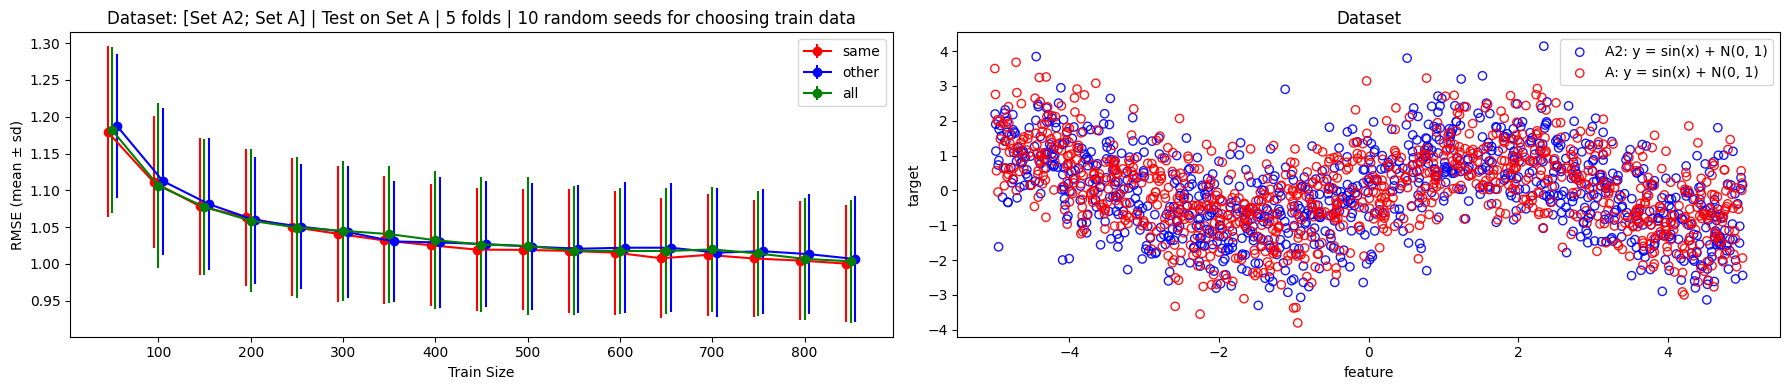

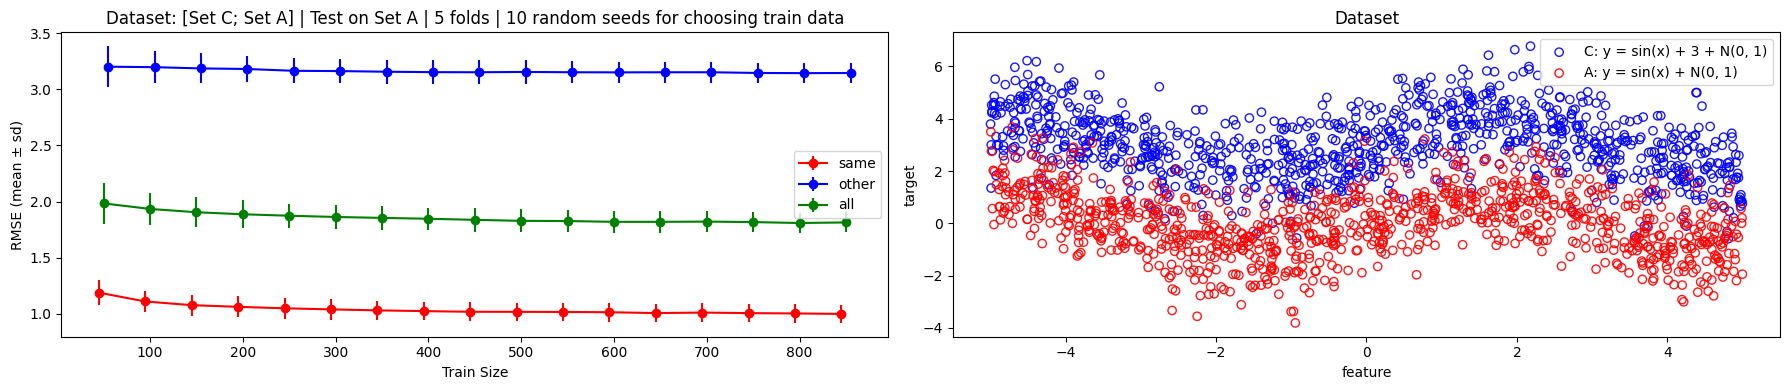

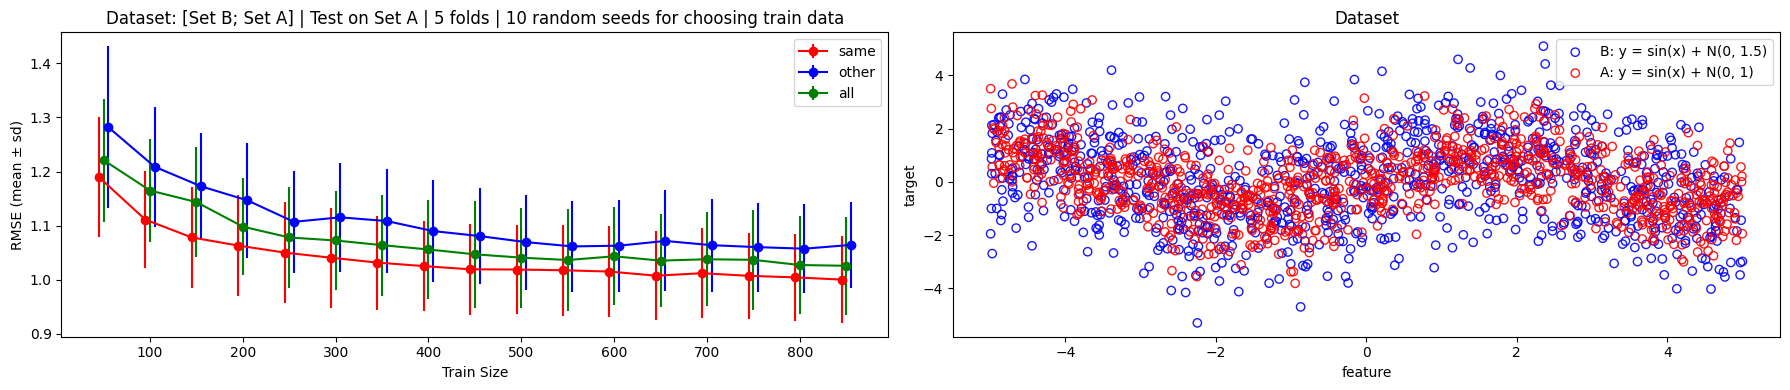

In [9]:
shift = {
    "same":  -5,
    "all":   0,
    "other": 5,
}
for other_name, same_name, train_df, test_df in cases:
    subset = final_df[(final_df["other_subset"] == other_name) & (final_df["same_subset"] == same_name)]
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
    # --- LEFT: RMSE error plot ---
    ax = axes[0]
    for category, color in zip(["same", "other", "all"], ["red", "blue", "green"]):
        data = subset[subset["category"] == category]
        ax.errorbar(data["train_size"] + shift[category], data["rmse_mean"], yerr=data["rmse_sd"], label=category, color=color, marker='o')
    
    ax.set_xlabel("Train Size")
    ax.set_ylabel("RMSE (mean ± sd)")
    ax.set_title(f"Dataset: [Set {other_name}; Set {same_name}] | Test on Set A | 5 folds | 10 random seeds for choosing train data")
    ax.legend()
    
    # --- RIGHT: raw data scatter ---
    ax = axes[1]
    ax.scatter(train_df["x"], train_df["y"], facecolors="none", edgecolors="blue", label=f"{other_name}: {label[other_name]}", alpha=0.9)
    ax.scatter(test_df["x"],  test_df["y"],  facecolors="none", edgecolors="red", label=f"{same_name}: {label[same_name]}", alpha=0.9)
    
    ax.set_xlabel("feature")
    ax.set_ylabel("target")
    ax.set_title("Dataset")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

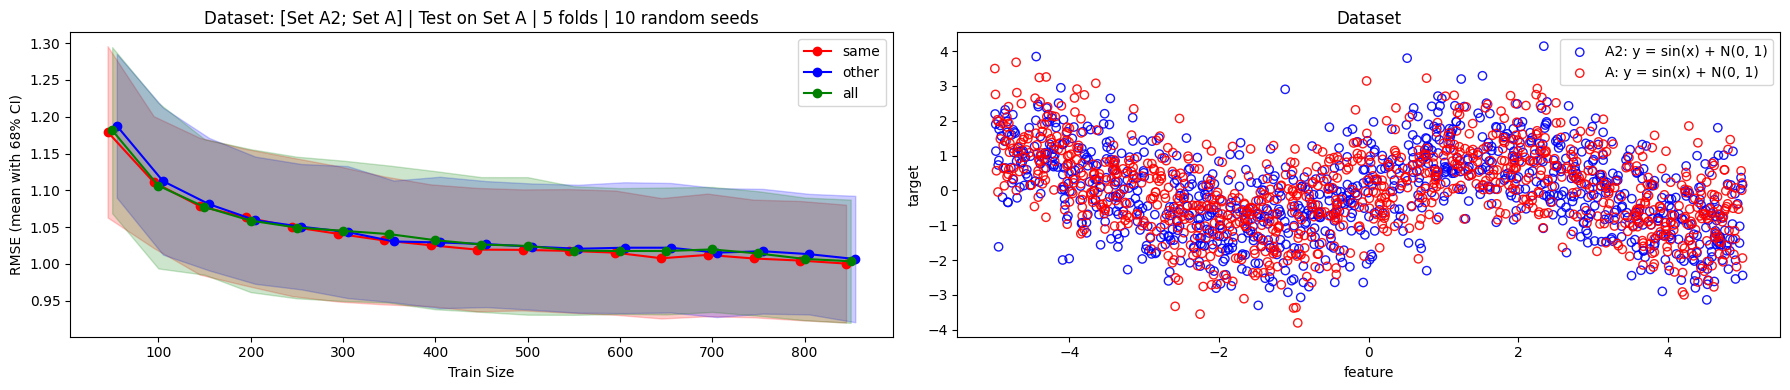

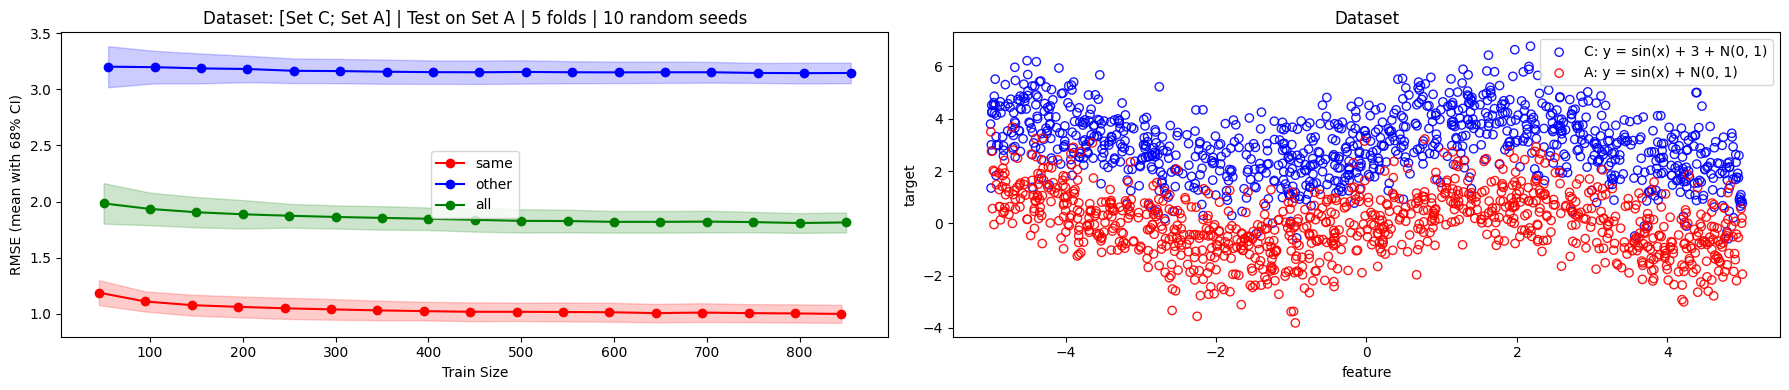

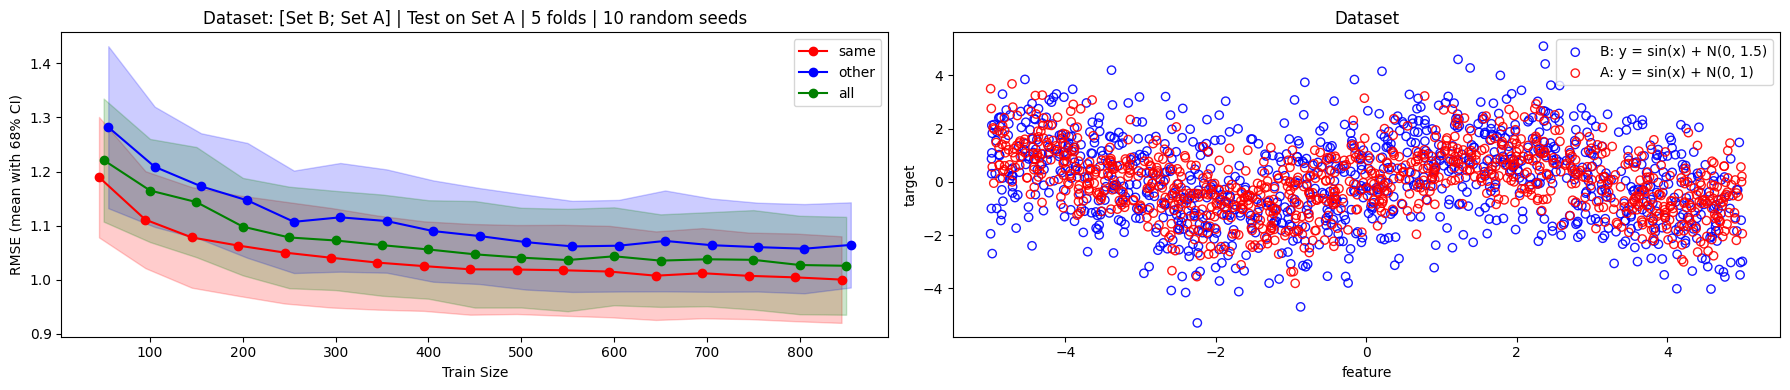

In [ ]:
for other_name, same_name, train_df, test_df in cases:
    subset = final_df[(final_df["other_subset"] == other_name) & (final_df["same_subset"] == same_name)]
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    
    # --- LEFT: RMSE error plot ---
    ax = axes[0]
    for category, color in zip(["same", "other", "all"], ["red", "blue", "green"]):
        data = subset[subset["category"] == category].sort_values("train_size")
        x = data["train_size"] + shift[category]
        mean = data["rmse_mean"]
        ci = data["rmse_sd"]
        # line
        ax.plot(x, mean, label=category, color=color, marker='o')
        ax.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.2)

    ax.set_xlabel("Train Size")
    ax.set_ylabel("RMSE (mean with 68% CI)")
    ax.set_title(f"Dataset: [Set {other_name}; Set {same_name}] | Test on Set A | 5 folds | 10 random seeds")
    ax.legend()
    
    # --- RIGHT: raw data scatter ---
    ax = axes[1]
    ax.scatter(train_df["x"], train_df["y"], facecolors="none", edgecolors="blue", label=f"{other_name}: {label[other_name]}", alpha=0.9)
    ax.scatter(test_df["x"],  test_df["y"],  facecolors="none", edgecolors="red", label=f"{same_name}: {label[same_name]}", alpha=0.9)
    
    ax.set_xlabel("feature")
    ax.set_ylabel("target")
    ax.set_title("Dataset")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
z = 1.96  # 95% CI

ax = axes[0]

for category, color in zip(["same", "other", "all"], ["red", "blue", "green"]):
    data = subset[subset["category"] == category].sort_values("train_size")
    
    x = data["train_size"] + shift[category]
    mean = data["rmse_mean"]
    ci = z * data["rmse_sd"] / np.sqrt(50)

    # line
    ax.plot(x, mean, label=category, color=color, marker='o')
    
    # shaded confidence region
    ax.fill_between(
        x,
        mean - ci,
        mean + ci,
        color=color,
        alpha=0.2
    )

ax.set_xlabel("Train Size")
ax.set_ylabel("RMSE (mean with 95% CI)")
ax.set_title(f"Dataset: [Set {other_name}; Set {same_name}] | Test on Set A | 5 folds | 10 random seeds")
ax.legend()

TypeError: Axes.imshow() missing 1 required positional argument: 'X'